# 22. Context Engineering

**Tier:** Agent Engineering
**Estimated time:** 50 minutes
**Prerequisites:** 13, 14, 21
**Priority:** 🔴 Crucial — Write/Select/Compress/Isolate are daily agent-engineering vocabulary. *If skipped, revisit when:* n/a.
**Source material:** @sairahul1 — AI Engineer Roadmap (https://x.com/sairahul1/status/2062809249064141017)

## What You'll Learn
- The four context primitives every agent engineer uses: **Write, Select, Compress, Isolate**
- How each one decides what occupies the limited context window at any moment
- Why context engineering, not prompt wording, is what keeps long-running agents coherent

## Why This Matters
Notebook 21 said the context window is the agent's RAM. This notebook is about *managing* that RAM. A long-running agent (dozens of turns, large documents, many tool results) will blow its context budget or drown in irrelevant history unless you deliberately control what goes in. These four primitives are that control.


## Four ways to manage what's in the window

The context window (notebook 13) is small and shared. As an agent runs, pressure builds: conversation history grows, tool results pile up, retrieved documents compete for space. Context engineering is the discipline of deciding, at each step, what actually deserves to be in the window. Four primitives cover it:

1. **Write** — push information *out* of the window into durable storage (a file, a scratchpad, a memory store) so it's not lost when the window fills. This is notebook 21's JSON tracker, generalized.
2. **Select** — pull *only the relevant* information back *in* when needed. This is retrieval (notebook 14): instead of keeping everything in context, fetch the few pieces that matter for the current step.
3. **Compress** — shrink what's in the window without losing meaning: summarize old conversation turns, collapse a long tool result into its key points. Trades fidelity for space.
4. **Isolate** — give a sub-task its *own clean context* so it doesn't pollute (or get polluted by) the main one. A sub-agent (notebook 20) handling one chunk doesn't need the whole history.

The mental model: **Write** and **Select** are the two halves of external memory (out, then back in selectively); **Compress** makes the in-window content smaller; **Isolate** prevents cross-contamination. A capable agent uses all four, constantly.


In [1]:
import os, json, pathlib, tempfile
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready.")
else:
    client = None
    print("No ANTHROPIC_API_KEY — generation cells will be skipped.")

def ask(prompt, system="You are concise.", max_tokens=250):
    if not HAS_ANTHROPIC:
        return "[skipped: no ANTHROPIC_API_KEY]"
    try:
        msg = client.messages.create(model=TEACH_MODEL, max_tokens=max_tokens,
                                      system=system, messages=[{"role": "user", "content": prompt}])
        return msg.content[0].text
    except Exception as e:
        return f"[skipped: {type(e).__name__}: {str(e)[:120]}]"

CTX_DIR = pathlib.Path(tempfile.mkdtemp(prefix="ctx22_"))


Anthropic ready.


## Primitive 1 — Write: offload to durable memory

When an agent learns a fact it'll need later, it writes it out rather than hoping it survives in the window. Here, a `remember` function persists notes to disk (a scratchpad memory).


In [2]:
MEMORY_FILE = CTX_DIR / "memory.json"
MEMORY_FILE.write_text("[]")

def remember(fact):
    """Write a fact to durable memory (outside the context window)."""
    mem = json.loads(MEMORY_FILE.read_text())
    mem.append(fact)
    MEMORY_FILE.write_text(json.dumps(mem, indent=2))

def all_memories():
    return json.loads(MEMORY_FILE.read_text())

remember("The customer's robot is a Helios X1, serial HX1-4471.")
remember("They are in timezone CET and prefer email contact.")
remember("Their warranty expires 2026-03-01.")
print("Stored", len(all_memories()), "facts outside the window:")
for m in all_memories():
    print("  -", m)


Stored 3 facts outside the window:
  - The customer's robot is a Helios X1, serial HX1-4471.
  - They are in timezone CET and prefer email contact.
  - Their warranty expires 2026-03-01.


## Primitive 2 — Select: retrieve only what's relevant

Instead of stuffing *all* memories into every prompt, select the ones relevant to the current question. With three facts we could keep them all — but at 10,000 facts you must select. We reuse embedding retrieval from notebook 14.


In [3]:
import sys
sys.path.insert(0, "..")
from ragkit.embeddings import embed, cosine_similarity

def select_relevant(query, memories, k=1):
    """Pull only the top-k memories relevant to `query` back into context."""
    if not memories:
        return []
    mem_vecs = embed(memories)
    q_vec = embed([query])
    sims = cosine_similarity(q_vec, mem_vecs)
    top = sims.argsort()[::-1][:k]
    return [memories[i] for i in top]

question = "When does this customer's coverage run out?"
selected = select_relevant(question, all_memories(), k=1)
print("Selected into context:", selected)

answer = ask(f"Context: {selected}\n\nQuestion: {question}")
print("Answer:", answer)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Selected into context: ['Their warranty expires 2026-03-01.']


Answer: The customer's coverage runs out on **March 1, 2026**.


## Primitive 3 — Compress: summarize to reclaim space

A 30-turn conversation won't fit forever. Compression replaces a chunk of old history with a short summary — keeping the gist, dropping the bulk.


In [4]:
long_history = [
    "User: My X1 won't connect to wifi.",
    "Assistant: Let's reset the wifi module — hold reset 10s.",
    "User: Did that, LED went red.",
    "Assistant: Red LED means firmware mismatch; update via the app.",
    "User: Updated, now it connects but drops every hour.",
    "Assistant: Hourly drops often indicate a DHCP lease issue; set a static IP.",
    "User: Static IP set, stable for a day now.",
    "Assistant: Great — mark this resolved?",
    "User: Yes, resolved.",
]

def compress(history):
    """Replace a long history with a short summary to reclaim window space."""
    joined = "\n".join(history)
    return ask(f"Summarize this support conversation in 2 sentences, keeping the resolution:\n{joined}",
               max_tokens=120)

summary = compress(long_history)
chars_before = sum(len(h) for h in long_history)
print(f"Before: {chars_before} chars across {len(long_history)} turns")
print(f"After:  {len(summary)} chars (1 summary)")
print("\nCompressed memory:", summary)


Before: 409 chars across 9 turns
After:  301 chars (1 summary)

Compressed memory: User's X1 device had recurring wifi connectivity issues that were resolved through three troubleshooting steps: resetting the wifi module, updating the firmware via the app, and setting a static IP address to fix the hourly disconnections. The device is now stable and the issue is marked as resolved.


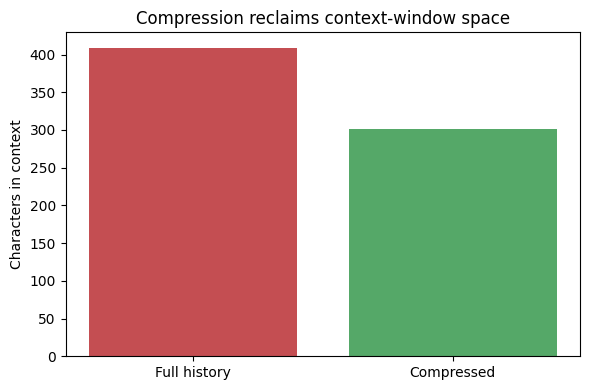

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(["Full history", "Compressed"], [chars_before, len(summary)], color=["#C44E52", "#55A868"])
plt.title("Compression reclaims context-window space")
plt.ylabel("Characters in context")
plt.tight_layout(); plt.show()


*Compression trades some detail for a large space saving — the agent keeps the resolution and drops the blow-by-blow, freeing the window for new work.*


## Primitive 4 — Isolate: give sub-tasks their own context

When a sub-task (e.g. analyzing one document) doesn't need the main conversation, run it in an isolated context — a fresh sub-agent call with only the inputs it needs. The main window stays clean; the sub-task stays focused.


In [6]:
def isolated_subtask(document, instruction):
    """Run a sub-task in its OWN clean context — no main-conversation history leaks in."""
    # A fresh, minimal message list: only what this sub-task needs.
    return ask(f"{instruction}\n\n<document>\n{document}\n</document>",
               system="You analyze a single document in isolation.", max_tokens=120)

doc_a = "Incident INC-2024-011: gripper reed switch false-open at low pressure. Resolved by firmware patch."
doc_b = "Incident INC-2024-019: battery thermal near-miss at MedLogix. Added cycle-count checks."

# Each runs isolated — neither sees the other's context, nor the main conversation.
summary_a = isolated_subtask(doc_a, "Summarize the root cause in one line.")
summary_b = isolated_subtask(doc_b, "Summarize the root cause in one line.")
print("Isolated summary A:", summary_a)
print("Isolated summary B:", summary_b)
print("\nMain context stays clean; only these one-line results come back.")


Isolated summary A: # Summary

The gripper reed switch was falsely triggering an open state at low pressure conditions, which was corrected through a firmware update.
Isolated summary B: The root cause was the absence of cycle-count checks for battery thermal management, leading to a near-miss incident at MedLogix.

Main context stays clean; only these one-line results come back.


## Exercises


In [7]:
# Exercise 1 (Warm-up): Select more facts
# Task: Add 5 more memories with remember(), then call select_relevant with k=3 for a question.
#       Confirm it returns the 3 most relevant, not just any 3.
# Hint: Selection quality depends entirely on the embeddings (notebook 03) — try a question whose
#       relevant fact uses different words than the fact itself.
remember("The Helios X1 was first distributed in January 1st, 2026")
remember("Its profit in Q1 2026 exceeded any other robotics company")
remember("Investors gained twice their investment value")
remember("The robot serves both as a chatbot and can make coffee")
remember("Following the success of the product, all warranties were extended by 3 months")
memories = all_memories()
select_relevant("Is my warranty still valid today?", memories=memories, k=3)

# YOUR CODE HERE


['Following the success of the product, all warranties were extended by 3 months',
 'Their warranty expires 2026-03-01.',
 'Its profit in Q1 2026 exceeded any other robotics company']

In [14]:
# Exercise 2 (Apply): Compress-on-threshold
# Task: Write a function add_turn(history, turn) that appends to a running history, and once the
#       history exceeds N characters, automatically compresses the OLDEST half into a summary.
# Hint: This is the real pattern behind "infinite" chat agents — compress old turns, keep recent
#       ones verbatim.

# YOUR CODE HERE
N = 300
from typing import List
def add_turn(history: List[str], turn: List[str]) -> List[str]:
    new_history = history.copy() + turn
    lens = [len(x) for x in new_history]
    new_len = sum(lens)
    if new_len < N:
        return new_history
    iter_len = 0
    summary_latest_index = 0
    for i, message in enumerate(new_history):
        if iter_len + len(message) >= N // 2:
            summary_latest_index = i
            break
        iter_len += len(message)
    summary_prompt = new_history[:summary_latest_index + 1]
    summary = compress(summary_prompt)
    new_history = [summary] + new_history[summary_latest_index + 1:]
    return new_history

    
    


In [15]:
# Tests for add_turn

# 1. Under the threshold: turn is appended verbatim, no compression triggered.
result = add_turn(["User: hi"], ["Assistant: hello"])
assert result == ["User: hi", "Assistant: hello"], f"expected simple append, got {result}"

# 2. Empty turn: history is returned unchanged.
result = add_turn(["User: hi"], [])
assert result == ["User: hi"], f"expected unchanged history, got {result}"

# 3. Over the threshold: oldest turns collapse into one summary, most recent turn stays verbatim.
total_chars = sum(len(h) for h in long_history)
assert total_chars >= N, "fixture should exceed N so this test actually exercises compression"
result = add_turn(long_history[:-1], [long_history[-1]])
assert len(result) < len(long_history), f"expected fewer entries after compression, got {len(result)}"
assert result[-1] == long_history[-1], "most recent turn must survive uncompressed"
assert result[0] != long_history[0], "oldest turn should have been replaced by a summary"

print("All add_turn tests passed.")


All add_turn tests passed.


In [ ]:
# Exercise 3 (Extend): Combine all four
# Task: Sketch (in code or comments) a customer-support agent that uses all four primitives:
#       Write new facts to memory, Select relevant ones per question, Compress old history, and
#       Isolate document analysis. Which primitive does the most work in YOUR design?
# Hint: This is essentially the context strategy the P3 capstone uses — there's no single right
#       answer, but every long-running agent needs all four.

# Customer support design - 
# Selection is the heavy lifting component here. Writing new facts to memory would be heavy in the beginning of the product and should have sessions baked in at the beginning, and addition after every iteration.
# Compression is 3rd, which would be used in long chats and complex bugs.  Isolation is the weakest - costumer supports shouldn't have multiple distinct functions or tools.


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for f in ["Customer name is Dana Roth.", "Site has 4 robots.", "Last service was 2025-11.",
          "Preferred language is German.", "Account tier is enterprise."]:
    remember(f)
print(select_relevant("How many machines are on site?", all_memories(), k=3))
# 'machines' != 'robots' in words, but embeddings place them close, so the robot-count fact ranks high.

# Exercise 2
def add_turn(history, turn, max_chars=400):
    history.append(turn)
    if sum(len(h) for h in history) > max_chars:
        half = len(history) // 2
        old_summary = compress(history[:half])
        history = ["[summary] " + old_summary] + history[half:]
    return history
h = []
for t in long_history:
    h = add_turn(h, t)
print(h[0][:120], "...")   # oldest turns collapsed into a summary

# Exercise 3
# Design: per incoming message ->
#   Select: retrieve relevant memories + relevant KB chunks (notebook 14) for THIS question.
#   Isolate: if the question references a specific incident doc, analyze it in a sub-agent.
#   Write: persist any new fact the customer states (serial, preference) to memory.
#   Compress: when history > threshold, summarize old turns.
# Select usually does the most work — it's what keeps the window small AND relevant every turn.
```
</details>


## Key Takeaways
- Context engineering manages the agent's RAM: deciding what occupies the limited window at each step.
- **Write** offloads to durable storage; **Select** retrieves only what's relevant back in — together they form external memory.
- **Compress** shrinks in-window content (summarize old turns); **Isolate** gives sub-tasks a clean, separate context.
- Selection quality rides on embeddings (notebook 03); compression trades fidelity for space; isolation prevents cross-contamination.
- Long-running agents need all four constantly — this, not prompt wording, is what keeps them coherent over many turns.

## What's Next
Notebook **23 — Loop Engineering** is the capstone of the tier: how to wrap these agents in *outer loops* — verification, tournaments, generate-and-filter — that catch the failures a single agent run won't catch on its own.
